# 10x Visium 空間トランスクリプトーム解析

このノートブックでは 10x Genomics Visium データの読み込み、QC、正規化、クラスタリング、空間可視化の基本フローを実行します。

## 1. 環境・パス設定

In [50]:
import os
import sys
from pathlib import Path
from pprint import pprint

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

In [3]:
# プロジェクトルート（リポジトリ直下で jupyter を起動するか、notebooks/ から実行するかで自動判定）
PROJECT_ROOT = Path.cwd() if (Path.cwd() / "config").exists() else Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [4]:
from config import load_config, get_paths
from src.preprocessing import (
    add_qc_metrics,
    filter_cells_and_genes,
    normalize_and_hvg,
)
# from src.clustering import build_spatial_neighbors, run_moran_i

In [5]:
# ディスプレイ設定
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=200, facecolor="white")

In [59]:
# パス設定
paths = get_paths(PROJECT_ROOT)
paths

{'project_root': PosixPath('/Users/kie/projects/spatial-transcriptomics'),
 'data_raw': PosixPath('/Users/kie/projects/spatial-transcriptomics/data/raw'),
 'data_processed': PosixPath('/Users/kie/projects/spatial-transcriptomics/data/processed'),
 'results': PosixPath('/Users/kie/projects/spatial-transcriptomics/results'),
 'notebooks': PosixPath('/Users/kie/projects/spatial-transcriptomics/notebooks'),
 'scripts': PosixPath('/Users/kie/projects/spatial-transcriptomics/scripts')}

In [88]:
# QC設定をconfig.yamlから読み込む
cfg = load_config(PROJECT_ROOT)
pprint(cfg)

{'clustering': {'method': 'leiden', 'resolution': 1.0},
 'dimension_reduction': {'neighbors_k': 15,
                         'pca_n_components': 50,
                         'umap_min_dist': 0.5},
 'export': {'dpi': 150,
            'plot_format': 'png',
            'run_name': 'run',
            'save_anndata': True,
            'save_plots': True},
 'feature_selection': {'method': 'hvg', 'n_top_genes': 2000},
 'inputs': {'sample_id': 'breast_cancer',
            'spaceranger_out_dir': '',
            'tissue_image_path': ''},
 'markers': {'method': 'wilcoxon', 'n_genes': 50},
 'normalization': {'method': 'log1p', 'target_sum': 10000},
 'project': {'description': '',
             'name': 'spatial-transcriptomics',
             'random_seed': 0},
 'qc': {'max_hb_percent': None,
        'max_mito_percent': None,
        'max_ribo_percent': None,
        'min_cells': 5,
        'min_counts_per_spot': 3000,
        'min_genes': 0,
        'min_genes_per_spot': 500,
        'n_top_genes': 

In [60]:
# sample_idをサンプルパスに変換
sample_path = paths["data_raw"] / cfg["inputs"]["sample_id"]
print(sample_path)

/Users/kie/projects/spatial-transcriptomics/data/raw/breast_cancer


## 2. Visium データの読み込み

In [89]:
# H5 ファイルを検索
h5_files = list(sample_path.glob("*_filtered_feature_bc_matrix.h5"))

# ファイルが見つからない場合はエラー
if not h5_files:
    raise FileNotFoundError(f"No h5 file found in {sample_path}")

adata = sc.read_visium(
    path = sample_path,
    count_file = h5_files[0]
)
# 遺伝子名（var_names）が重複している場合、自動的に一意になるよう修正
adata.var_names_make_unique()

reading /Users/kie/projects/spatial-transcriptomics/data/raw/breast_cancer/Visium_Human_Breast_Cancer_filtered_feature_bc_matrix.h5


/var/folders/kw/xx_sgnvd31794nt0j1vgkx700000gn/T/ipykernel_5530/597356836.py:8: FutureWarning: Use `squidpy.read.visium` instead.
  adata = sc.read_visium(


 (0:00:00)


/Users/kie/projects/spatial-transcriptomics/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/kie/projects/spatial-transcriptomics/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [79]:
print(adata.shape)          # 行列サイズ
print(adata.obs.head())     # 細胞/スポット情報
print(adata.var.head())     # 遺伝子情報

(4898, 36601)
                    in_tissue  array_row  array_col
AAACAACGAATAGTTC-1          1          0         16
AAACAAGTATCTCCCA-1          1         50        102
AAACAATCTACTAGCA-1          1          3         43
AAACACCAATAACTGC-1          1         59         19
AAACAGAGCGACTCCT-1          1         14         94
                    gene_ids    feature_types  genome
MIR1302-2HG  ENSG00000243485  Gene Expression  GRCh38
FAM138A      ENSG00000237613  Gene Expression  GRCh38
OR4F5        ENSG00000186092  Gene Expression  GRCh38
AL627309.1   ENSG00000238009  Gene Expression  GRCh38
AL627309.3   ENSG00000239945  Gene Expression  GRCh38


/var/folders/kw/xx_sgnvd31794nt0j1vgkx700000gn/T/ipykernel_5530/3288414031.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata)


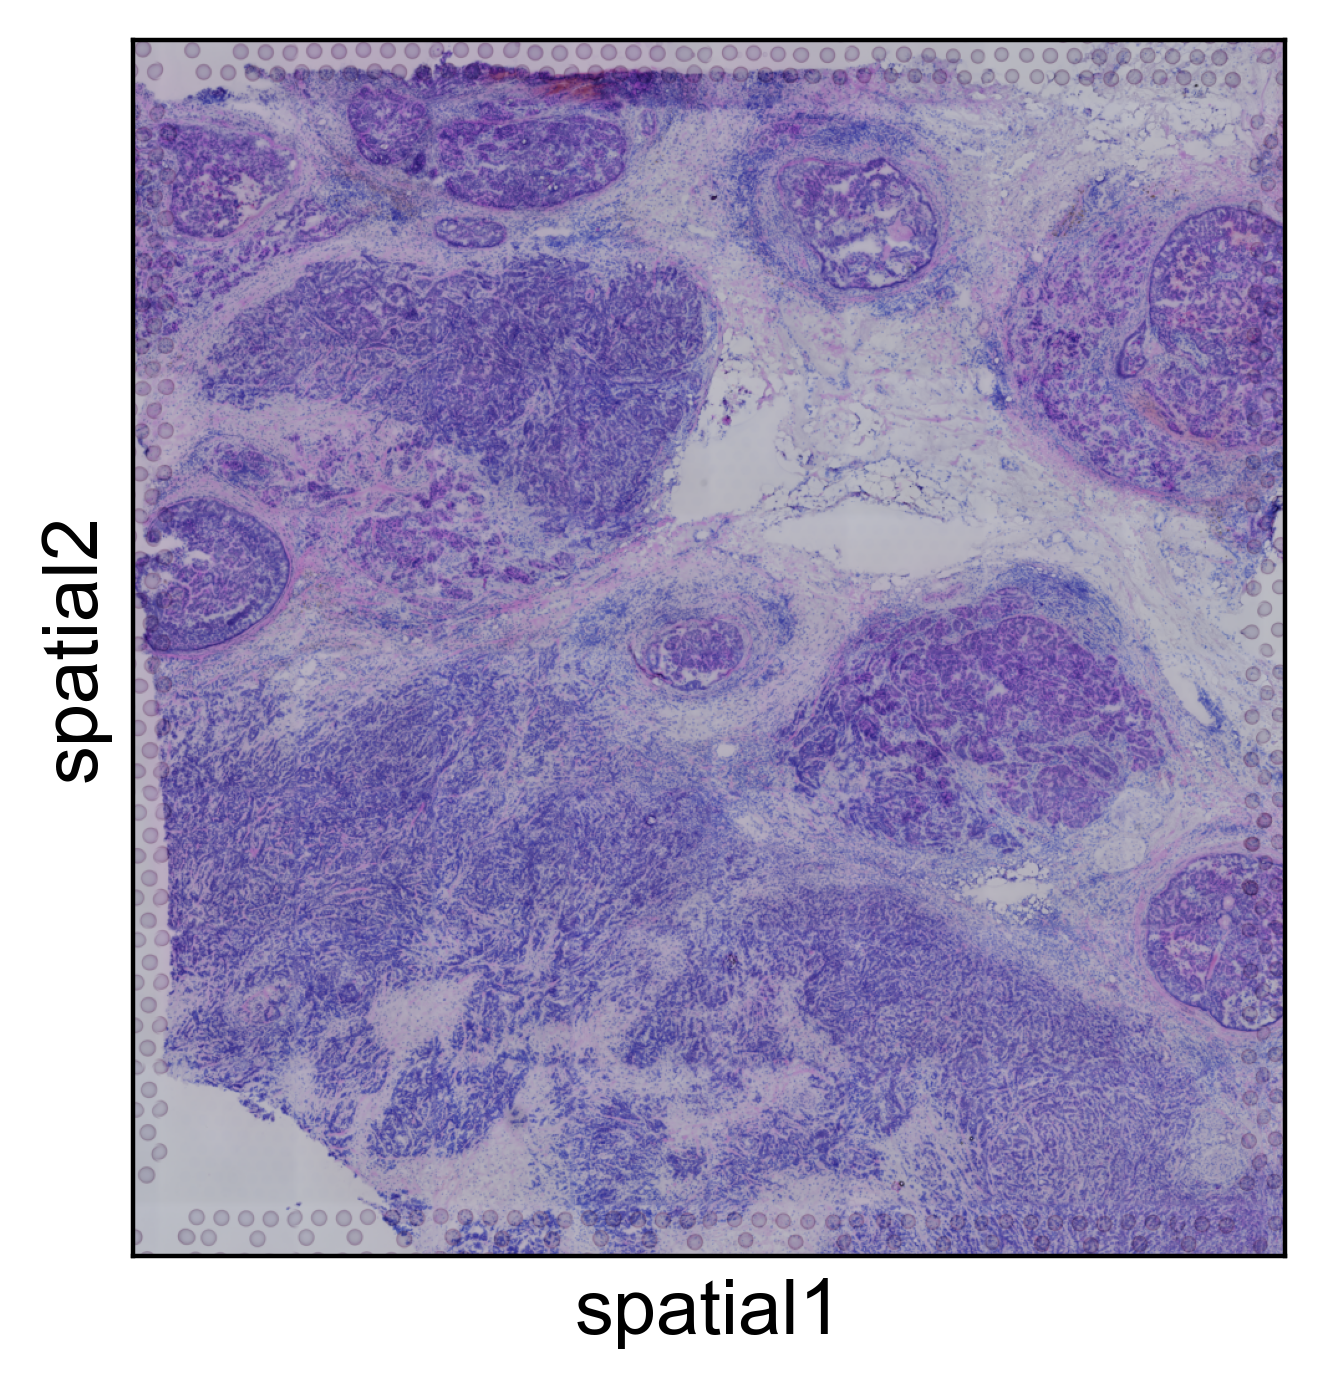

In [80]:
sc.pl.spatial(adata)

/var/folders/kw/xx_sgnvd31794nt0j1vgkx700000gn/T/ipykernel_5530/4273259600.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


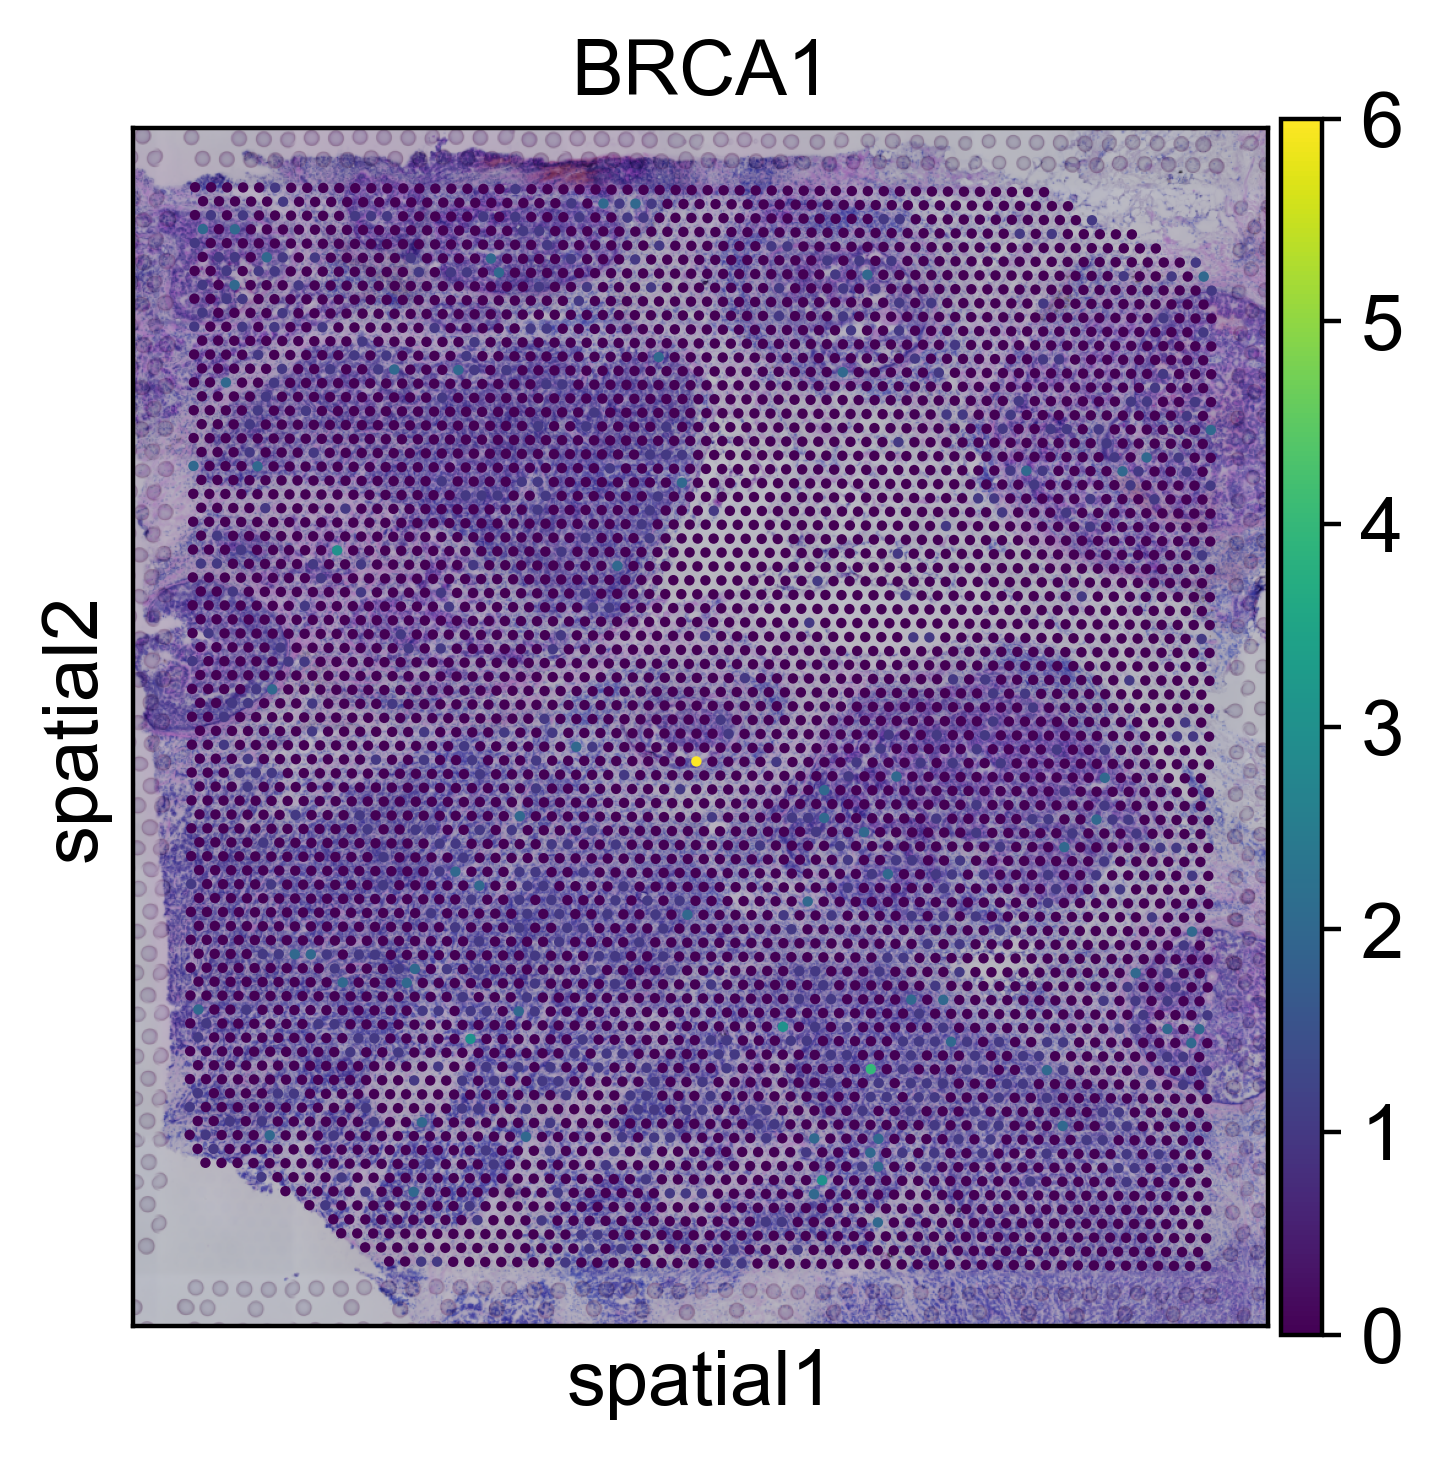

In [71]:
sc.pl.spatial(
    adata,
    color="BRCA1"
)

## 3. QC とフィルタリング

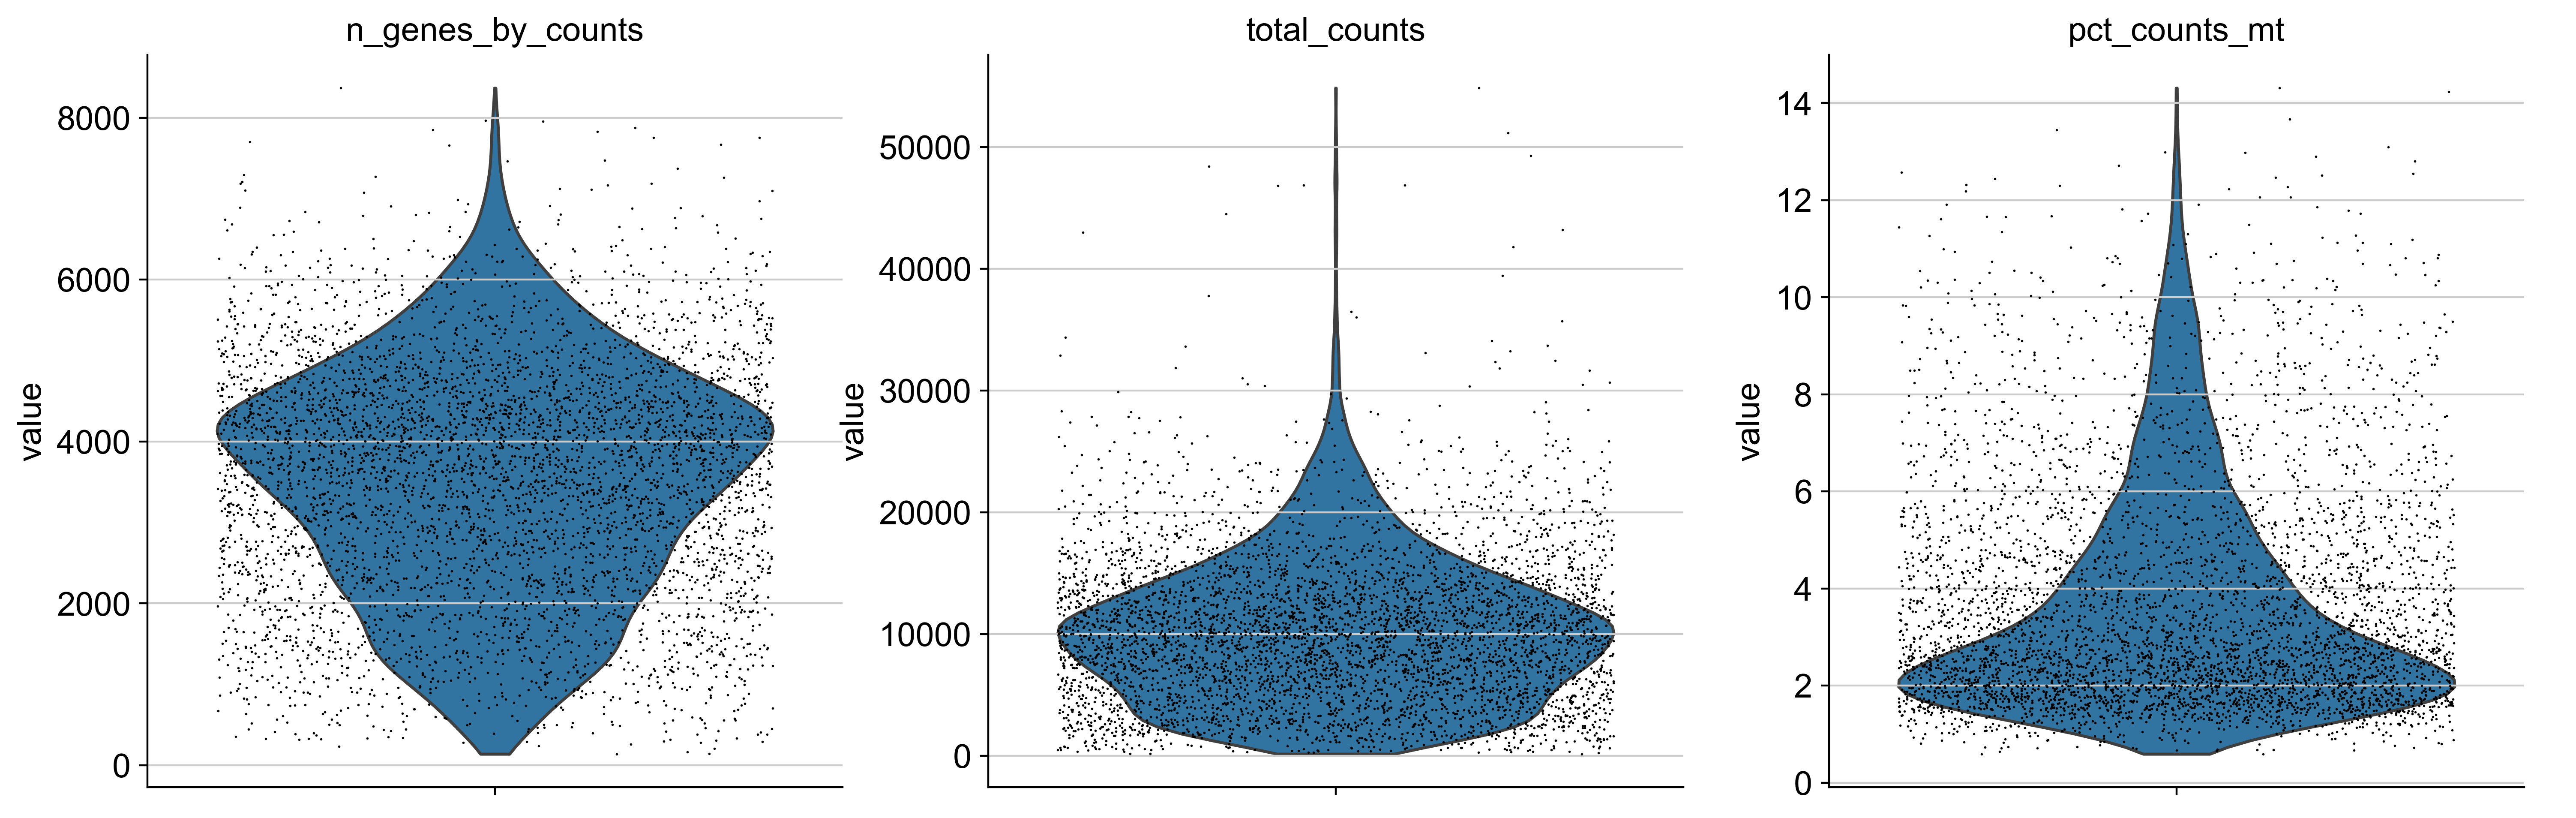

In [90]:
add_qc_metrics(adata)
sc.pl.violin(adata, ["n_genes_by_counts", "total_counts", "pct_counts_mt"], jitter=0.4, multi_panel=True)

In [91]:
adata = filter_cells_and_genes(
    adata,
    min_genes = cfg["qc"]["min_genes"],
    min_cells = cfg["qc"]["min_genes_per_spot"],
    pct_counts_mt_max = cfg["qc"]["pct_counts_mt_max"],
)
print(adata)

filtered out 27153 genes that are detected in less than 500 cells
AnnData object with n_obs × n_vars = 4876 × 9448
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'spatial'
    obsm: 'spatial'


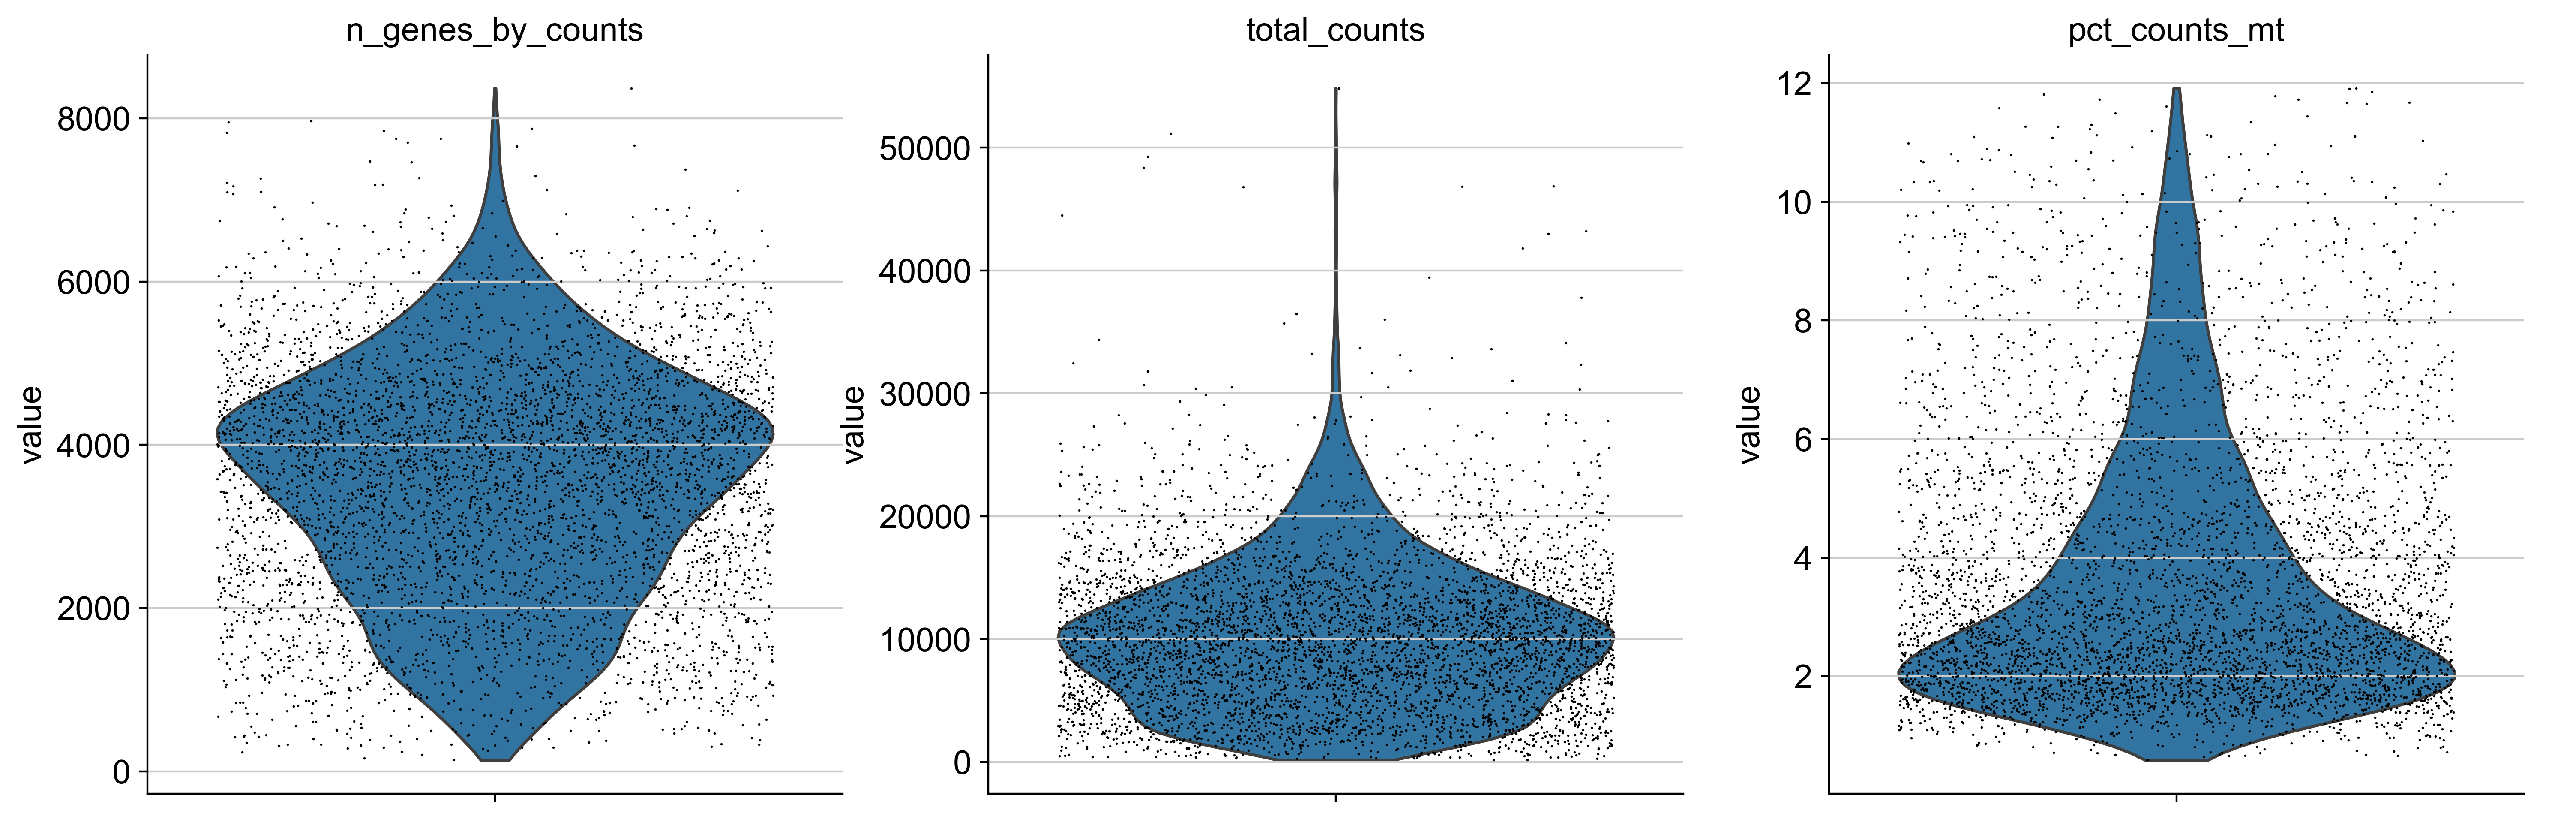

In [92]:
sc.pl.violin(adata, ["n_genes_by_counts", "total_counts", "pct_counts_mt"], jitter=0.4, multi_panel=True)

## 4. 正規化とログ変換

In [ ]:
adata = normalize_and_hvg(adata, n_top_genes=cfg["feature_selection"]["n_top_genes"])

## 5. スケールと PCA・クラスタリング

In [ ]:
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, svd_solver="arpack")
sc.pl.pca_variance_ratio(adata, n_pcs=20)

sc.pp.neighbors(adata, n_neighbors=qc_cfg["n_neighbors"], n_pcs=qc_cfg["n_pcs"])
sc.tl.leiden(adata, resolution=qc_cfg["leiden_resolution"])
sc.tl.umap(adata)

## 6. 空間・UMAP 可視化

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sc.pl.umap(adata, color="leiden", ax=axes[0], show=False)
sc.pl.spatial(adata, color="leiden", ax=axes[1], show=False)
plt.tight_layout()
plt.show()

## 7. 遺伝子発現の空間プロット

In [ ]:
genes = adata.var_names[:4].tolist()  # または ['GENE1', 'GENE2', ...]
sc.pl.spatial(adata, color=genes, cmap="viridis", ncols=2)

## 8. Squidpy: 空間隣接とモランI

In [ ]:
build_spatial_neighbors(adata, coord_type="generic", delaunay=True)
run_moran_i(adata, n_genes=100)

adata.uns["moranI"].sort_values("I", ascending=False).head(10)

## 9. 結果の保存

In [ ]:
out_dir = paths["data_processed"]
out_dir.mkdir(parents=True, exist_ok=True)
adata.write(out_dir / f"{SAMPLE_ID}_processed.h5ad")